# Final Corpus Classification — Gemini 3.1 Pro (v2)

Manual batch classification workflow. Since the Gemini API is not available, this notebook:
1. **Generates the prompt** to copy-paste into Gemini.
2. **Provides a cell** to paste Gemini's response.
3. **Parses and evaluates** the results automatically.

> **Note:** The standard / irony / obfuscated splits share identical test sets within each corpus type.

## Dependencies

In [1]:
import os
import re

import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

import watermark

%load_ext watermark
%matplotlib inline

plt.style.use('../style.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
%watermark -n -v -m -iv

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.4.0

Compiler    : Clang 16.0.0 (clang-1600.0.26.6)
OS          : Darwin
Release     : 25.5.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

re        : 2.2.1
seaborn   : 0.13.2
watermark : 2.5.0
matplotlib: 3.10.5
pandas    : 2.3.1
sklearn   : 1.7.1



## Prompt builder

In [3]:
SYSTEM_MSG = "Sos un clasificador binario de tweets que hablan sobre drogas ilícitas"

CRITERIA = """\
    Clasifica cada tweet como POSITIVE o NEGATIVE según estos criterios:

    POSITIVE: cumple con uno o más de los siguientes:
    - El usuario del tweet habla de cómo o qué tipo de droga ilícita está consumiendo.
    - El usuario del tweet expresa la necesidad de consumir drogas ilícitas, ya sea por abstinencia o por gusto.
    - El usuario añora consumir drogas ilícitas.

    NEGATIVE: no cumple con ningún criterio POSITIVE, por ejemplo:
    - Habla sobre noticias o información general sobre drogas ilícitas.
    - Menciona drogas ilícitas sin relación con consumo problemático o necesidad.
    - Expresa ironía o sarcasmo relacionado con drogas ilícitas.

    Tener en cuenta los siguientes aspectos:
    - En el tweet puede estar presente la ironía o sarcasmo.
    - El análisis se centra en el autor del tweet. Por ejemplo, si el tweet cita a otro usuario y le pregunta si ha consumido drogas, o si habla en nombre de otro usuario mencionando que ese usuario consume drogas, la clasificación del tweet debe ser NEGATIVE, ya que el contenido no involucra directamente al autor.
    - Algunos tweets mencionan tomar una línea de colectivo, subte o tren, pero solamente esto, no es condición suficiente para interpretarlo como una referencia al consumo de drogas ilícitas."""

def build_batch_prompt(tweets: list[str]) -> str:
    numbered = "\n".join(f"{i+1}. {t}" for i, t in enumerate(tweets))
    return (
        f"[System instruction: {SYSTEM_MSG}]\n\n"
        + CRITERIA
        + "\n\n"
        + "Responde con una lista numerada, exactamente una clasificación por línea, "
        + "únicamente la palabra POSITIVE o NEGATIVE (sin puntuación adicional ni explicaciones):\n\n"
        + numbered
    )

def parse_batch_response(response_text: str, n: int) -> list[str]:
    lines = [l.strip() for l in response_text.strip().splitlines() if l.strip()]
    results = []
    for line in lines:
        cleaned = re.sub(r"^\d+[.)\s]+", "", line).strip().upper().rstrip(".")
        if cleaned in ("POSITIVE", "NEGATIVE"):
            results.append(cleaned)
    if len(results) != n:
        raise ValueError(f"Expected {n} classifications, got {len(results)}. Response:\n{response_text}")
    return results

## Corpus types

In [4]:
CORPORA = [
    ("raw-corpus",           "../data/raw/final-corpus/raw-corpus/standard/test.csv"),
    ("pre-filtered-corpus",  "../data/raw/final-corpus/pre-filtered-corpus/standard/test.csv"),
]

## Step 1 — Generate prompts to paste into Gemini

Run this cell, then copy each prompt into [Gemini](https://gemini.google.com/) and paste the response in **Step 2**.

In [5]:
dfs = {}
prompts = {}

for corpus_label, csv_path in CORPORA:
    df = pd.read_csv(csv_path)
    dfs[corpus_label] = df
    tweets = df["text"].tolist()
    prompt = build_batch_prompt(tweets)
    prompts[corpus_label] = prompt

    print(f"\n{'='*70}")
    print(f"PROMPT FOR: {corpus_label}  ({len(tweets)} tweets)")
    print(f"{'='*70}")
    print(prompt)
    print(f"\n{'='*70}\n")


PROMPT FOR: raw-corpus  (450 tweets)
[System instruction: Sos un clasificador binario de tweets que hablan sobre drogas ilícitas]

    Clasifica cada tweet como POSITIVE o NEGATIVE según estos criterios:

    POSITIVE: cumple con uno o más de los siguientes:
    - El usuario del tweet habla de cómo o qué tipo de droga ilícita está consumiendo.
    - El usuario del tweet expresa la necesidad de consumir drogas ilícitas, ya sea por abstinencia o por gusto.
    - El usuario añora consumir drogas ilícitas.

    NEGATIVE: no cumple con ningún criterio POSITIVE, por ejemplo:
    - Habla sobre noticias o información general sobre drogas ilícitas.
    - Menciona drogas ilícitas sin relación con consumo problemático o necesidad.
    - Expresa ironía o sarcasmo relacionado con drogas ilícitas.

    Tener en cuenta los siguientes aspectos:
    - En el tweet puede estar presente la ironía o sarcasmo.
    - El análisis se centra en el autor del tweet. Por ejemplo, si el tweet cita a otro usuario y

## Step 2 — Paste Gemini responses here

After running each prompt in Gemini, paste the full response into the corresponding variable below.

> Leave the string empty (`""`) for corpora you haven't run yet.

In [6]:
# Paste Gemini's response for each corpus below:

GEMINI_RESPONSES = {
    "raw-corpus": """1. POSITIVE
2. NEGATIVE
3. NEGATIVE
4. NEGATIVE
5. NEGATIVE
6. POSITIVE
7. POSITIVE
8. NEGATIVE
9. NEGATIVE
10. NEGATIVE
11. POSITIVE
12. POSITIVE
13. NEGATIVE
14. POSITIVE
15. NEGATIVE
16. NEGATIVE
17. POSITIVE
18. NEGATIVE
19. POSITIVE
20. POSITIVE
21. POSITIVE
22. NEGATIVE
23. NEGATIVE
24. NEGATIVE
25. POSITIVE
26. POSITIVE
27. POSITIVE
28. POSITIVE
29. POSITIVE
30. NEGATIVE
31. NEGATIVE
32. NEGATIVE
33. NEGATIVE
34. NEGATIVE
35. NEGATIVE
36. NEGATIVE
37. POSITIVE
38. POSITIVE
39. POSITIVE
40. POSITIVE
41. POSITIVE
42. NEGATIVE
43. NEGATIVE
44. NEGATIVE
45. NEGATIVE
46. POSITIVE
47. POSITIVE
48. POSITIVE
49. NEGATIVE
50. POSITIVE
51. NEGATIVE
52. POSITIVE
53. POSITIVE
54. NEGATIVE
55. NEGATIVE
56. NEGATIVE
57. POSITIVE
58. NEGATIVE
59. NEGATIVE
60. NEGATIVE
61. NEGATIVE
62. NEGATIVE
63. NEGATIVE
64. POSITIVE
65. POSITIVE
66. NEGATIVE
67. NEGATIVE
68. POSITIVE
69. POSITIVE
70. NEGATIVE
71. NEGATIVE
72. NEGATIVE
73. POSITIVE
74. NEGATIVE
75. NEGATIVE
76. NEGATIVE
77. POSITIVE
78. NEGATIVE
79. NEGATIVE
80. NEGATIVE
81. NEGATIVE
82. POSITIVE
83. POSITIVE
84. POSITIVE
85. NEGATIVE
86. NEGATIVE
87. POSITIVE
88. POSITIVE
89. NEGATIVE
90. POSITIVE
91. NEGATIVE
92. POSITIVE
93. POSITIVE
94. NEGATIVE
95. NEGATIVE
96. NEGATIVE
97. NEGATIVE
98. NEGATIVE
99. NEGATIVE
100. NEGATIVE
101. POSITIVE
102. NEGATIVE
103. POSITIVE
104. NEGATIVE
105. NEGATIVE
106. NEGATIVE
107. POSITIVE
108. NEGATIVE
109. POSITIVE
110. NEGATIVE
111. NEGATIVE
112. NEGATIVE
113. POSITIVE
114. NEGATIVE
115. POSITIVE
116. NEGATIVE
117. NEGATIVE
118. POSITIVE
119. NEGATIVE
120. POSITIVE
121. NEGATIVE
122. NEGATIVE
123. POSITIVE
124. NEGATIVE
125. NEGATIVE
126. NEGATIVE
127. POSITIVE
128. POSITIVE
129. NEGATIVE
130. NEGATIVE
131. POSITIVE
132. POSITIVE
133. POSITIVE
134. NEGATIVE
135. POSITIVE
136. POSITIVE
137. NEGATIVE
138. NEGATIVE
139. POSITIVE
140. POSITIVE
141. POSITIVE
142. NEGATIVE
143. NEGATIVE
144. NEGATIVE
145. NEGATIVE
146. POSITIVE
147. NEGATIVE
148. NEGATIVE
149. NEGATIVE
150. NEGATIVE
151. NEGATIVE
152. POSITIVE
153. POSITIVE
154. POSITIVE
155. NEGATIVE
156. NEGATIVE
157. POSITIVE
158. POSITIVE
159. NEGATIVE
160. NEGATIVE
161. POSITIVE
162. POSITIVE
163. POSITIVE
164. POSITIVE
165. POSITIVE
166. NEGATIVE
167. POSITIVE
168. NEGATIVE
169. NEGATIVE
170. NEGATIVE
171. NEGATIVE
172. NEGATIVE
173. NEGATIVE
174. NEGATIVE
175. NEGATIVE
176. NEGATIVE
177. NEGATIVE
178. POSITIVE
179. POSITIVE
180. NEGATIVE
181. POSITIVE
182. NEGATIVE
183. NEGATIVE
184. NEGATIVE
185. POSITIVE
186. POSITIVE
187. NEGATIVE
188. NEGATIVE
189. NEGATIVE
190. POSITIVE
191. NEGATIVE
192. NEGATIVE
193. NEGATIVE
194. NEGATIVE
195. NEGATIVE
196. NEGATIVE
197. NEGATIVE
198. NEGATIVE
199. POSITIVE
200. NEGATIVE
201. NEGATIVE
202. NEGATIVE
203. POSITIVE
204. NEGATIVE
205. POSITIVE
206. NEGATIVE
207. NEGATIVE
208. NEGATIVE
209. NEGATIVE
210. NEGATIVE
211. NEGATIVE
212. POSITIVE
213. NEGATIVE
214. NEGATIVE
215. POSITIVE
216. POSITIVE
217. NEGATIVE
218. POSITIVE
219. NEGATIVE
220. NEGATIVE
221. NEGATIVE
222. POSITIVE
223. NEGATIVE
224. POSITIVE
225. NEGATIVE
226. NEGATIVE
227. POSITIVE
228. POSITIVE
229. NEGATIVE
230. NEGATIVE
231. NEGATIVE
232. POSITIVE
233. NEGATIVE
234. POSITIVE
235. POSITIVE
236. NEGATIVE
237. POSITIVE
238. POSITIVE
239. NEGATIVE
240. NEGATIVE
241. NEGATIVE
242. NEGATIVE
243. NEGATIVE
244. POSITIVE
245. NEGATIVE
246. POSITIVE
247. NEGATIVE
248. NEGATIVE
249. POSITIVE
250. POSITIVE
251. POSITIVE
252. NEGATIVE
253. NEGATIVE
254. NEGATIVE
255. POSITIVE
256. POSITIVE
257. NEGATIVE
258. POSITIVE
259. POSITIVE
260. NEGATIVE
261. POSITIVE
262. NEGATIVE
263. NEGATIVE
264. NEGATIVE
265. NEGATIVE
266. NEGATIVE
267. NEGATIVE
268. NEGATIVE
269. POSITIVE
270. POSITIVE
271. NEGATIVE
272. POSITIVE
273. NEGATIVE
274. POSITIVE
275. POSITIVE
276. POSITIVE
277. NEGATIVE
278. POSITIVE
279. NEGATIVE
280. POSITIVE
281. NEGATIVE
282. POSITIVE
283. NEGATIVE
284. POSITIVE
285. NEGATIVE
286. NEGATIVE
287. POSITIVE
288. NEGATIVE
289. NEGATIVE
290. NEGATIVE
291. NEGATIVE
292. NEGATIVE
293. POSITIVE
294. NEGATIVE
295. POSITIVE
296. NEGATIVE
297. POSITIVE
298. POSITIVE
299. NEGATIVE
300. POSITIVE
301. NEGATIVE
302. NEGATIVE
303. NEGATIVE
304. NEGATIVE
305. NEGATIVE
306. NEGATIVE
307. POSITIVE
308. NEGATIVE
309. NEGATIVE
310. POSITIVE
311. NEGATIVE
312. POSITIVE
313. POSITIVE
314. POSITIVE
315. NEGATIVE
316. POSITIVE
317. POSITIVE
318. NEGATIVE
319. NEGATIVE
320. NEGATIVE
321. POSITIVE
322. POSITIVE
323. POSITIVE
324. NEGATIVE
325. NEGATIVE
326. POSITIVE
327. POSITIVE
328. POSITIVE
329. POSITIVE
330. NEGATIVE
331. NEGATIVE
332. POSITIVE
333. NEGATIVE
334. NEGATIVE
335. NEGATIVE
336. NEGATIVE
337. POSITIVE
338. POSITIVE
339. POSITIVE
340. POSITIVE
341. NEGATIVE
342. POSITIVE
343. NEGATIVE
344. NEGATIVE
345. NEGATIVE
346. POSITIVE
347. NEGATIVE
348. NEGATIVE
349. NEGATIVE
350. POSITIVE
351. POSITIVE
352. POSITIVE
353. NEGATIVE
354. NEGATIVE
355. NEGATIVE
356. NEGATIVE
357. POSITIVE
358. NEGATIVE
359. NEGATIVE
360. NEGATIVE
361. NEGATIVE
362. NEGATIVE
363. NEGATIVE
364. POSITIVE
365. POSITIVE
366. NEGATIVE
367. NEGATIVE
368. NEGATIVE
369. NEGATIVE
370. NEGATIVE
371. NEGATIVE
372. NEGATIVE
373. POSITIVE
374. NEGATIVE
375. NEGATIVE
376. POSITIVE
377. NEGATIVE
378. NEGATIVE
379. POSITIVE
380. NEGATIVE
381. POSITIVE
382. NEGATIVE
383. NEGATIVE
384. NEGATIVE
385. NEGATIVE
386. POSITIVE
387. NEGATIVE
388. NEGATIVE
389. POSITIVE
390. POSITIVE
391. POSITIVE
392. NEGATIVE
393. NEGATIVE
394. POSITIVE
395. NEGATIVE
396. POSITIVE
397. NEGATIVE
398. NEGATIVE
399. NEGATIVE
400. POSITIVE
401. NEGATIVE
402. NEGATIVE
403. NEGATIVE
404. NEGATIVE
405. NEGATIVE
406. NEGATIVE
407. NEGATIVE
408. NEGATIVE
409. NEGATIVE
410. NEGATIVE
411. POSITIVE
412. POSITIVE
413. NEGATIVE
414. NEGATIVE
415. NEGATIVE
416. POSITIVE
417. POSITIVE
418. NEGATIVE
419. POSITIVE
420. NEGATIVE
421. POSITIVE
422. NEGATIVE
423. POSITIVE
424. POSITIVE
425. NEGATIVE
426. NEGATIVE
427. NEGATIVE
428. POSITIVE
429. NEGATIVE
430. NEGATIVE
431. NEGATIVE
432. NEGATIVE
433. POSITIVE
434. NEGATIVE
435. POSITIVE
436. POSITIVE
437. NEGATIVE
438. NEGATIVE
439. NEGATIVE
440. NEGATIVE
441. POSITIVE
442. POSITIVE
443. NEGATIVE
444. NEGATIVE
445. POSITIVE
446. NEGATIVE
447. NEGATIVE
448. NEGATIVE
449. NEGATIVE
450. NEGATIVE
""",
    "pre-filtered-corpus": """1. POSITIVE
2. NEGATIVE
3. POSITIVE
4. NEGATIVE
5. NEGATIVE
6. NEGATIVE
7. POSITIVE
8. NEGATIVE
9. NEGATIVE
10. POSITIVE
11. POSITIVE
12. NEGATIVE
13. NEGATIVE
14. NEGATIVE
15. NEGATIVE
16. POSITIVE
17. POSITIVE
18. NEGATIVE
19. NEGATIVE
20. POSITIVE
21. POSITIVE
22. NEGATIVE
23. NEGATIVE
24. NEGATIVE
25. POSITIVE
26. POSITIVE
27. POSITIVE
28. NEGATIVE
29. POSITIVE
30. NEGATIVE
31. NEGATIVE
32. NEGATIVE
33. NEGATIVE
34. NEGATIVE
35. NEGATIVE
36. NEGATIVE
37. NEGATIVE
38. NEGATIVE
39. POSITIVE
40. POSITIVE
41. POSITIVE
42. NEGATIVE
43. POSITIVE
44. NEGATIVE
45. NEGATIVE
46. NEGATIVE
47. POSITIVE
48. POSITIVE
49. NEGATIVE
50. POSITIVE
51. POSITIVE
52. NEGATIVE
53. NEGATIVE
54. NEGATIVE
55. NEGATIVE
56. NEGATIVE
57. NEGATIVE
58. NEGATIVE
59. NEGATIVE
60. POSITIVE
61. NEGATIVE
62. NEGATIVE
63. POSITIVE
64. NEGATIVE
65. NEGATIVE
66. NEGATIVE
67. POSITIVE
68. NEGATIVE
69. POSITIVE
70. NEGATIVE
71. NEGATIVE
72. NEGATIVE
73. POSITIVE
74. NEGATIVE
75. NEGATIVE
76. POSITIVE
77. NEGATIVE
78. NEGATIVE
79. NEGATIVE
80. NEGATIVE
81. NEGATIVE
82. NEGATIVE
83. POSITIVE
84. POSITIVE
85. NEGATIVE
86. NEGATIVE
87. POSITIVE
88. POSITIVE
89. NEGATIVE
90. POSITIVE
91. NEGATIVE
92. NEGATIVE
93. POSITIVE
94. NEGATIVE
95. POSITIVE
96. NEGATIVE
97. NEGATIVE
98. NEGATIVE
99. NEGATIVE
100. NEGATIVE
101. POSITIVE
102. NEGATIVE
103. NEGATIVE
104. NEGATIVE
105. NEGATIVE
106. NEGATIVE
107. POSITIVE
108. NEGATIVE
109. NEGATIVE
110. NEGATIVE
111. POSITIVE
112. NEGATIVE
113. POSITIVE
114. POSITIVE
115. POSITIVE
116. NEGATIVE
117. NEGATIVE
118. POSITIVE
119. NEGATIVE
120. NEGATIVE
121. NEGATIVE
122. NEGATIVE
123. NEGATIVE
124. NEGATIVE
125. POSITIVE
126. NEGATIVE
127. POSITIVE
128. POSITIVE
129. NEGATIVE
130. NEGATIVE
131. POSITIVE
132. POSITIVE
133. NEGATIVE
134. NEGATIVE
135. POSITIVE
136. NEGATIVE
137. NEGATIVE
138. NEGATIVE
139. POSITIVE
140. POSITIVE
141. NEGATIVE
142. NEGATIVE
143. NEGATIVE
144. NEGATIVE
145. NEGATIVE
146. POSITIVE
147. NEGATIVE
148. NEGATIVE
149. NEGATIVE
150. NEGATIVE
151. NEGATIVE
152. POSITIVE
153. POSITIVE
154. POSITIVE
155. NEGATIVE
156. NEGATIVE
157. POSITIVE
158. POSITIVE
159. NEGATIVE
160. NEGATIVE
161. NEGATIVE
162. POSITIVE
163. POSITIVE
164. NEGATIVE
165. NEGATIVE
166. POSITIVE
167. NEGATIVE
168. NEGATIVE
169. NEGATIVE
170. NEGATIVE
171. NEGATIVE
172. NEGATIVE
173. NEGATIVE
174. POSITIVE
175. NEGATIVE
176. NEGATIVE
177. NEGATIVE
178. NEGATIVE
179. NEGATIVE
180. NEGATIVE
181. POSITIVE
182. POSITIVE
183. NEGATIVE
184. NEGATIVE
185. NEGATIVE
186. NEGATIVE
187. NEGATIVE
188. NEGATIVE
189. NEGATIVE
190. NEGATIVE
191. NEGATIVE
192. NEGATIVE
193. NEGATIVE
194. NEGATIVE
195. NEGATIVE
196. POSITIVE
197. NEGATIVE
198. NEGATIVE
199. POSITIVE
200. NEGATIVE
201. NEGATIVE
202. NEGATIVE
203. NEGATIVE
204. NEGATIVE
205. POSITIVE
206. NEGATIVE
207. POSITIVE
208. NEGATIVE
209. NEGATIVE
210. NEGATIVE
211. NEGATIVE
212. POSITIVE
213. NEGATIVE
214. NEGATIVE
215. NEGATIVE
216. POSITIVE
217. NEGATIVE
218. NEGATIVE
219. NEGATIVE
220. POSITIVE
221. NEGATIVE
222. POSITIVE
223. NEGATIVE
224. POSITIVE
225. POSITIVE
226. NEGATIVE
227. POSITIVE
228. NEGATIVE
229. NEGATIVE
230. NEGATIVE
231. POSITIVE
232. POSITIVE
233. NEGATIVE
234. POSITIVE
235. NEGATIVE
236. NEGATIVE
237. POSITIVE
238. NEGATIVE
239. NEGATIVE
240. NEGATIVE
241. NEGATIVE
242. NEGATIVE
243. NEGATIVE
244. NEGATIVE
245. NEGATIVE
246. POSITIVE
247. POSITIVE
248. NEGATIVE
249. POSITIVE
250. POSITIVE
251. NEGATIVE
252. NEGATIVE
253. NEGATIVE
254. NEGATIVE
255. POSITIVE
256. POSITIVE
257. NEGATIVE
258. NEGATIVE
259. POSITIVE
260. NEGATIVE
261. NEGATIVE
262. NEGATIVE
263. POSITIVE
264. POSITIVE
265. NEGATIVE
266. NEGATIVE
267. NEGATIVE
268. POSITIVE
269. NEGATIVE
270. POSITIVE
271. NEGATIVE
272. POSITIVE
273. NEGATIVE
274. NEGATIVE
275. POSITIVE
276. POSITIVE
277. NEGATIVE
278. POSITIVE
279. NEGATIVE
280. POSITIVE
281. NEGATIVE
282. NEGATIVE
283. NEGATIVE
284. POSITIVE
285. POSITIVE
286. NEGATIVE
287. POSITIVE
288. POSITIVE
289. POSITIVE
290. NEGATIVE
291. POSITIVE
292. POSITIVE
293. POSITIVE
294. POSITIVE
295. NEGATIVE
296. NEGATIVE
297. POSITIVE
298. NEGATIVE
299. NEGATIVE
300. POSITIVE
301. NEGATIVE
302. NEGATIVE
303. NEGATIVE
304. NEGATIVE
305. NEGATIVE
306. NEGATIVE
307. NEGATIVE
308. POSITIVE
309. POSITIVE
310. NEGATIVE
311. NEGATIVE
312. POSITIVE
313. NEGATIVE
314. POSITIVE
315. NEGATIVE
316. POSITIVE
317. NEGATIVE
318. NEGATIVE
319. POSITIVE
320. NEGATIVE
321. POSITIVE
322. NEGATIVE
323. POSITIVE
324. NEGATIVE
325. POSITIVE
326. POSITIVE
327. NEGATIVE
328. POSITIVE
329. NEGATIVE
330. NEGATIVE
331. NEGATIVE
332. NEGATIVE
333. NEGATIVE
334. POSITIVE
335. NEGATIVE
336. NEGATIVE
337. NEGATIVE
338. POSITIVE
339. NEGATIVE
340. POSITIVE
341. NEGATIVE
342. NEGATIVE
343. POSITIVE
344. NEGATIVE
345. NEGATIVE
346. POSITIVE
347. NEGATIVE
348. NEGATIVE
349. NEGATIVE
350. NEGATIVE
351. NEGATIVE
352. POSITIVE
353. NEGATIVE
354. NEGATIVE
355. NEGATIVE
356. NEGATIVE
357. POSITIVE
358. POSITIVE
359. POSITIVE
360. NEGATIVE
361. NEGATIVE
362. NEGATIVE
363. NEGATIVE
364. NEGATIVE
365. NEGATIVE
366. NEGATIVE
367. NEGATIVE
368. POSITIVE
369. NEGATIVE
370. NEGATIVE
371. NEGATIVE
372. NEGATIVE
373. POSITIVE
374. NEGATIVE
375. POSITIVE
376. POSITIVE
377. NEGATIVE
378. NEGATIVE
379. POSITIVE
380. NEGATIVE
381. POSITIVE
382. NEGATIVE
383. NEGATIVE
384. POSITIVE
385. POSITIVE
386. NEGATIVE
387. POSITIVE
388. NEGATIVE
389. POSITIVE
390. NEGATIVE
391. POSITIVE
392. NEGATIVE
393. NEGATIVE
394. POSITIVE
395. NEGATIVE
396. NEGATIVE
397. NEGATIVE
398. NEGATIVE
399. NEGATIVE
400. NEGATIVE
401. NEGATIVE
402. NEGATIVE
403. NEGATIVE
404. NEGATIVE
405. NEGATIVE
406. NEGATIVE
407. NEGATIVE
408. NEGATIVE
409. NEGATIVE
410. NEGATIVE
411. POSITIVE
412. NEGATIVE
413. NEGATIVE
414. NEGATIVE
415. NEGATIVE
416. POSITIVE
417. POSITIVE
418. POSITIVE
419. NEGATIVE
420. NEGATIVE
421. NEGATIVE
422. NEGATIVE
423. POSITIVE
424. POSITIVE
425. POSITIVE
426. NEGATIVE
427. POSITIVE
428. NEGATIVE
429. NEGATIVE
430. NEGATIVE
431. NEGATIVE
432. NEGATIVE
433. POSITIVE
434. NEGATIVE
435. NEGATIVE
436. POSITIVE
437. NEGATIVE
438. NEGATIVE
439. NEGATIVE
440. NEGATIVE
441. POSITIVE
442. POSITIVE
443. NEGATIVE
444. NEGATIVE
445. NEGATIVE
446. POSITIVE
447. POSITIVE
448. NEGATIVE
449. POSITIVE
450. NEGATIVE
""",
}

## Step 3 — Parse responses and compute metrics


Corpus: raw-corpus


/var/folders/d7/53rh3m0d4j983v3p54wjrlf80000gn/T/ipykernel_13685/561331472.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


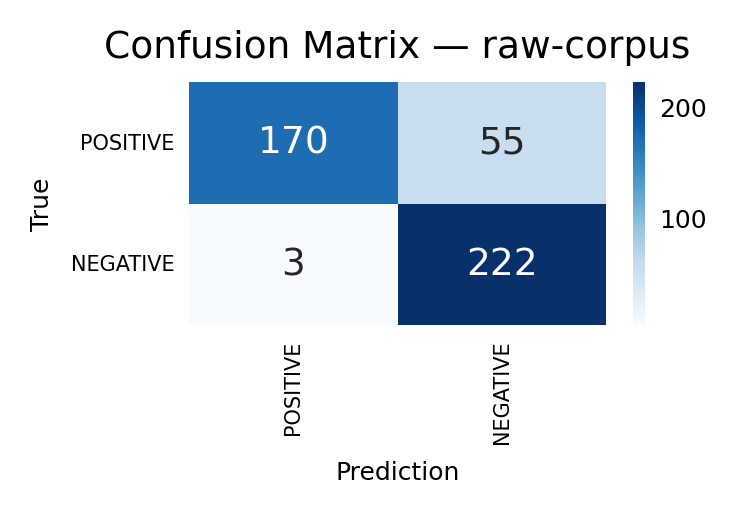

[[170  55]
 [  3 222]]

Classification report:


,precision,recall,f1-score,support
POSITIVE,0.98,0.76,0.85,225
NEGATIVE,0.80,0.99,0.88,225
accuracy,0.87,0.87,0.87,1
macro avg,0.89,0.87,0.87,450
weighted avg,0.89,0.87,0.87,450



Wrongly classified: 58


,text,label,prediction
2,me quiero tomar una línea tan larga que tenga ...,POSITIVE,NEGATIVE
9,Este es el momento en el que me gustaría inyec...,POSITIVE,NEGATIVE
15,Inyectarme heroina en el trabajo no me hace me...,POSITIVE,NEGATIVE
42,Mi meta para este 2022 es inyectarme heroína,POSITIVE,NEGATIVE
45,"me gustaría inyectarme heroína, así veo todo r...",NEGATIVE,POSITIVE
50,mi idea de diversión es ver 10 películas en un...,POSITIVE,NEGATIVE
59,Hace años tuve una época decadente. Una vez sa...,POSITIVE,NEGATIVE
66,Nose si tomarme una línea o que me choque una ...,POSITIVE,NEGATIVE
75,Necesito esa libertad de poder inyectarme hero...,POSITIVE,NEGATIVE
94,"No le veo nada de malo a fumarse un porro, per...",POSITIVE,NEGATIVE



Corpus: pre-filtered-corpus


/var/folders/d7/53rh3m0d4j983v3p54wjrlf80000gn/T/ipykernel_13685/561331472.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


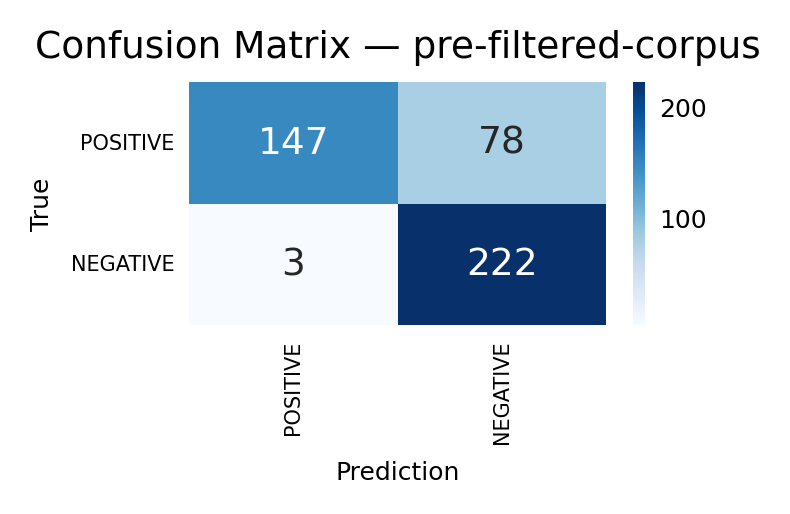

[[147  78]
 [  3 222]]

Classification report:


,precision,recall,f1-score,support
POSITIVE,0.98,0.65,0.78,225
NEGATIVE,0.74,0.99,0.85,225
accuracy,0.82,0.82,0.82,1
macro avg,0.86,0.82,0.81,450
weighted avg,0.86,0.82,0.81,450



Wrongly classified: 81


,text,label,prediction
5,Me voy a tomar una raya de merca cada vez que ...,POSITIVE,NEGATIVE
11,Me voy a tomar una linea para ser flaca como q...,POSITIVE,NEGATIVE
13,"""si queres vamos a fumar unas florcitas y toma...",POSITIVE,NEGATIVE
18,"Necesito inyectarme heroina ya, o no voy a pod...",POSITIVE,NEGATIVE
27,Tomar una línea de merca en la pija de un [DIS...,POSITIVE,NEGATIVE
...,...,...,...
420,Procedo a inyectarme heroína,POSITIVE,NEGATIVE
427,Estoy a dos segundos de empezar a inyectarme h...,POSITIVE,NEGATIVE
433,Hoy me di cuenta de que me puedo auto-ligar el...,POSITIVE,NEGATIVE
434,unas ganas de inyectarme heroina,POSITIVE,NEGATIVE


In [7]:
LABELS = ["POSITIVE", "NEGATIVE"]
results = {}

for corpus_label, _ in CORPORA:
    response_text = GEMINI_RESPONSES[corpus_label]
    if not response_text.strip() or response_text.strip().startswith("# PASTE"):
        print(f"Skipping {corpus_label} — no response pasted yet.")
        continue

    df = dfs[corpus_label].copy()
    try:
        predictions = parse_batch_response(response_text, len(df))
    except ValueError as e:
        print(f"Parse error for {corpus_label}: {e}")
        continue

    df["prediction"] = predictions
    results[corpus_label] = df

    y_true = df["label"]
    y_pred = df["prediction"]

    print(f"\n{'='*60}")
    print(f"Corpus: {corpus_label}")
    print(f"{'='*60}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(2, 1))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS,
                cbar=True, annot_kws={"size": 9}, ax=ax)
    ax.collections[0].colorbar.ax.tick_params(labelsize=6)
    ax.set_xlabel("Prediction", fontsize=6)
    ax.set_ylabel("True", fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_title(f"Confusion Matrix — {corpus_label}", fontsize=9)
    plt.tight_layout()
    plt.show()
    print(cm)

    # Classification report
    report = classification_report(y_true, y_pred, labels=LABELS, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print("\nClassification report:")
    display(report_df.style.format({"precision": "{:.2f}", "recall": "{:.2f}", "f1-score": "{:.2f}", "support": "{:.0f}"}))

    # Errors
    df["error"] = df["label"] != df["prediction"]
    errors = df[df["error"]][["text", "label", "prediction"]]
    print(f"\nWrongly classified: {len(errors)}")
    display(errors)

## Step 4 — Save wrongly-classified tweets

In [8]:
for corpus_label, _ in CORPORA:
    if corpus_label not in results:
        continue
    df = results[corpus_label]
    errors = df[df["label"] != df["prediction"]][["text", "label", "prediction"]]
    out_path = f"../data/processed/final-corpus/{corpus_label}/wct_gemini-3.1-pro-v2.csv"
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    errors.to_csv(out_path, index=False)
    print(f"Saved {len(errors)} errors → {out_path}")

Saved 58 errors → ../data/processed/final-corpus/raw-corpus/wct_gemini-3.1-pro-v2.csv
Saved 81 errors → ../data/processed/final-corpus/pre-filtered-corpus/wct_gemini-3.1-pro-v2.csv
